In [ ]:
# !pip install opencv-python numpy tqdm pillow
# !pip install matplotlib opencv-python

100%|██████████| 7000/7000 [00:36<00:00, 189.54it/s]


✅ Đã sinh 1249 ảnh mosaic và gộp chung với 1330 ảnh gốc.
📄 Tổng số ảnh trong dataset mới: 2579


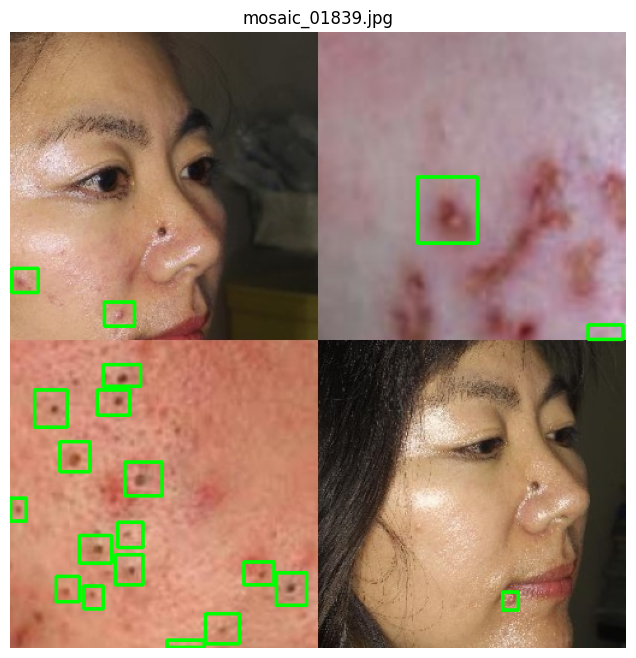

In [5]:
import os, cv2, json, random
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# ================== ĐƯỜNG DẪN ==================
input_dir = "train"
input_json = os.path.join(input_dir, "_annotations.coco.json")
output_dir = "train_aug"
os.makedirs(output_dir, exist_ok=True)
output_json = os.path.join(output_dir, "_annotations.coco.json")

# ================== ĐỌC COCO ==================
with open(input_json, "r", encoding="utf-8") as f:
    coco = json.load(f)

images = coco["images"]
annotations = coco["annotations"]
categories = coco["categories"]

# ================== MAP IMAGE -> ANNOTATION ==================
ann_by_img = {}
for ann in annotations:
    img_id = ann["image_id"]
    ann_by_img.setdefault(img_id, []).append(ann)

# ================== HÀM CROP ==================
def random_crop(img, boxes, labels, scale_range=(0.2, 0.8)):
    """
    Cắt ngẫu nhiên theo tỉ lệ (scale_range) của ảnh gốc.
    Trả về ảnh crop + bbox mới (đảm bảo không bị cat thanh 0).
    """
    h, w = img.shape[:2]
    scale = random.uniform(*scale_range)
    ch, cw = int(h * scale), int(w * scale)

    if w <= cw or h <= ch:
        return img, boxes, labels

    # Chọn vị trí crop ngẫu nhiên
    x0 = random.randint(0, w - cw)
    y0 = random.randint(0, h - ch)
    x1, y1 = x0 + cw, y0 + ch

    cropped_img = img[y0:y1, x0:x1]

    new_boxes, new_labels = [], []
    for box, label in zip(boxes, labels):
        bx1, by1, bx2, by2 = box
        # Kiểm tra box có giao với vùng crop
        if bx2 <= x0 or bx1 >= x1 or by2 <= y0 or by1 >= y1:
            continue
        # Tính lại box mới trong vùng crop
        nx1 = max(bx1 - x0, 0)
        ny1 = max(by1 - y0, 0)
        nx2 = min(bx2 - x0, cw)
        ny2 = min(by2 - y0, ch)
        # Giữ lại nếu box vẫn còn hợp lệ
        if (nx2 - nx1) / cw > 0.02 and (ny2 - ny1) / ch > 0.02:  # không quá nhỏ
            new_boxes.append([nx1, ny1, nx2, ny2])
            new_labels.append(label)

    return cropped_img, new_boxes, new_labels

# ================== HÀM MOSAIC ==================
def mosaic(images_boxes_labels, out_size=(512, 512)):
    h, w = out_size
    mosaic_img = np.zeros((h, w, 3), dtype=np.uint8)
    final_boxes, final_labels = [], []
    positions = [(0, 0), (0, w // 2), (h // 2, 0), (h // 2, w // 2)]
    for (img, boxes, labels), (y0, x0) in zip(images_boxes_labels, positions):
        img_resized = cv2.resize(img, (w // 2, h // 2))
        mosaic_img[y0:y0 + h // 2, x0:x0 + w // 2] = img_resized
        scale_x = (w / 2) / img.shape[1]
        scale_y = (h / 2) / img.shape[0]
        for box, label in zip(boxes, labels):
            bx1, by1, bx2, by2 = box
            nx1 = bx1 * scale_x + x0
            ny1 = by1 * scale_y + y0
            nx2 = bx2 * scale_x + x0
            ny2 = by2 * scale_y + y0
            if nx2 > nx1 and ny2 > ny1:
                final_boxes.append([nx1, ny1, nx2, ny2])
                final_labels.append(label)
    return mosaic_img, final_boxes, final_labels

# ================== SINH MOSAIC ==================
new_images, new_annotations = [], []
next_img_id = max(i["id"] for i in images) + 1
next_ann_id = max(a["id"] for a in annotations) + 1

num_out = 7000
for i in tqdm(range(num_out)):
    selected = random.sample(images, 4)
    imgs_boxes_labels = []
    for sel in selected:
        img_path = os.path.join(input_dir, sel["file_name"])
        img = cv2.imread(img_path)
        if img is None:
            continue
        anns = ann_by_img.get(sel["id"], [])
        boxes, labels = [], []
        for a in anns:
            x, y, w, h = a["bbox"]
            boxes.append([x, y, x + w, y + h])
            labels.append(a["category_id"])
        cropped_img, new_boxes, new_labels = random_crop(img, boxes, labels)
        if len(new_boxes) > 0:
            imgs_boxes_labels.append((cropped_img, new_boxes, new_labels))

    if len(imgs_boxes_labels) < 4:
        continue

    mosaic_img, boxes, labels = mosaic(imgs_boxes_labels)
    if len(boxes) == 0:
        continue

    out_name = f"mosaic_{i:05d}.jpg"
    cv2.imwrite(os.path.join(output_dir, out_name), mosaic_img)

    h, w = mosaic_img.shape[:2]
    new_images.append({"id": next_img_id, "file_name": out_name, "height": h, "width": w})
    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = box
        if x2 > x1 and y2 > y1:
            new_annotations.append({
                "id": next_ann_id,
                "image_id": next_img_id,
                "category_id": label,
                "bbox": [x1, y1, x2 - x1, y2 - y1],
                "area": (x2 - x1) * (y2 - y1),
                "iscrowd": 0
            })
            next_ann_id += 1
    next_img_id += 1

# ================== GỘP CẢ ẢNH GỐC + MOSAIC ==================
coco_out = {
    "images": images + new_images,
    "annotations": annotations + new_annotations,
    "categories": categories
}

with open(output_json, "w", encoding="utf-8") as f:
    json.dump(coco_out, f, ensure_ascii=False, indent=2)

print(f"✅ Đã sinh {len(new_images)} ảnh mosaic và gộp chung với {len(images)} ảnh gốc.")
print(f"📄 Tổng số ảnh trong dataset mới: {len(coco_out['images'])}")

# ================== VISUALIZE NGẪU NHIÊN ==================
sample = random.choice(new_images)
img_path = os.path.join(output_dir, sample["file_name"])
anns = [a for a in new_annotations if a["image_id"] == sample["id"]]

img = cv2.imread(img_path)
for a in anns:
    x, y, w, h = map(int, a["bbox"])
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(sample["file_name"])
plt.axis("off")
plt.show()


[⚠️] Không tìm thấy: train_aug\levle1_34_png_jpg.rf.292b6c3c0dacfbb4b0d1c0c5da617576.jpg
[⚠️] Không tìm thấy: train_aug\levle1_198_jpg.rf.29b402525f618ad8f3589a375e22050f.jpg
[⚠️] Không tìm thấy: train_aug\levle1_67_jpg.rf.2a2c474ff3e46ac510b07976f3e08f6d.jpg
[⚠️] Không tìm thấy: train_aug\01F3MMWASQXMT2JDT81P87MS6M_jpeg_jpg.rf.2a683222ebf5b8b2af130d2924919527.jpg
[⚠️] Không tìm thấy: train_aug\levle1_194_jpg.rf.2a6b381e2cd75098d6ffd889aa0714ea.jpg
[⚠️] Không tìm thấy: train_aug\levle3_72_jpg.rf.2a6e439c51245f77c670ef8692a8f58a.jpg
[⚠️] Không tìm thấy: train_aug\levle1_591_png_jpg.rf.2a829c96fc80c2cd2a1e7989ae3c6ca7.jpg
[⚠️] Không tìm thấy: train_aug\levle0_193_jpg.rf.2aa2a1319bde357eb6a75716083abbc2.jpg
[⚠️] Không tìm thấy: train_aug\levle1_502_jpg.rf.2b099a476e0ffe7730b6209b9e072778.jpg
[⚠️] Không tìm thấy: train_aug\levle0_98_jpg.rf.2b189a6d676ca2b37ea0d45d811b4ebd.jpg
[⚠️] Không tìm thấy: train_aug\levle1_347_png_jpg.rf.2b2297664f5439a670a905e7d058389f.jpg
[⚠️] Không tìm thấy: trai

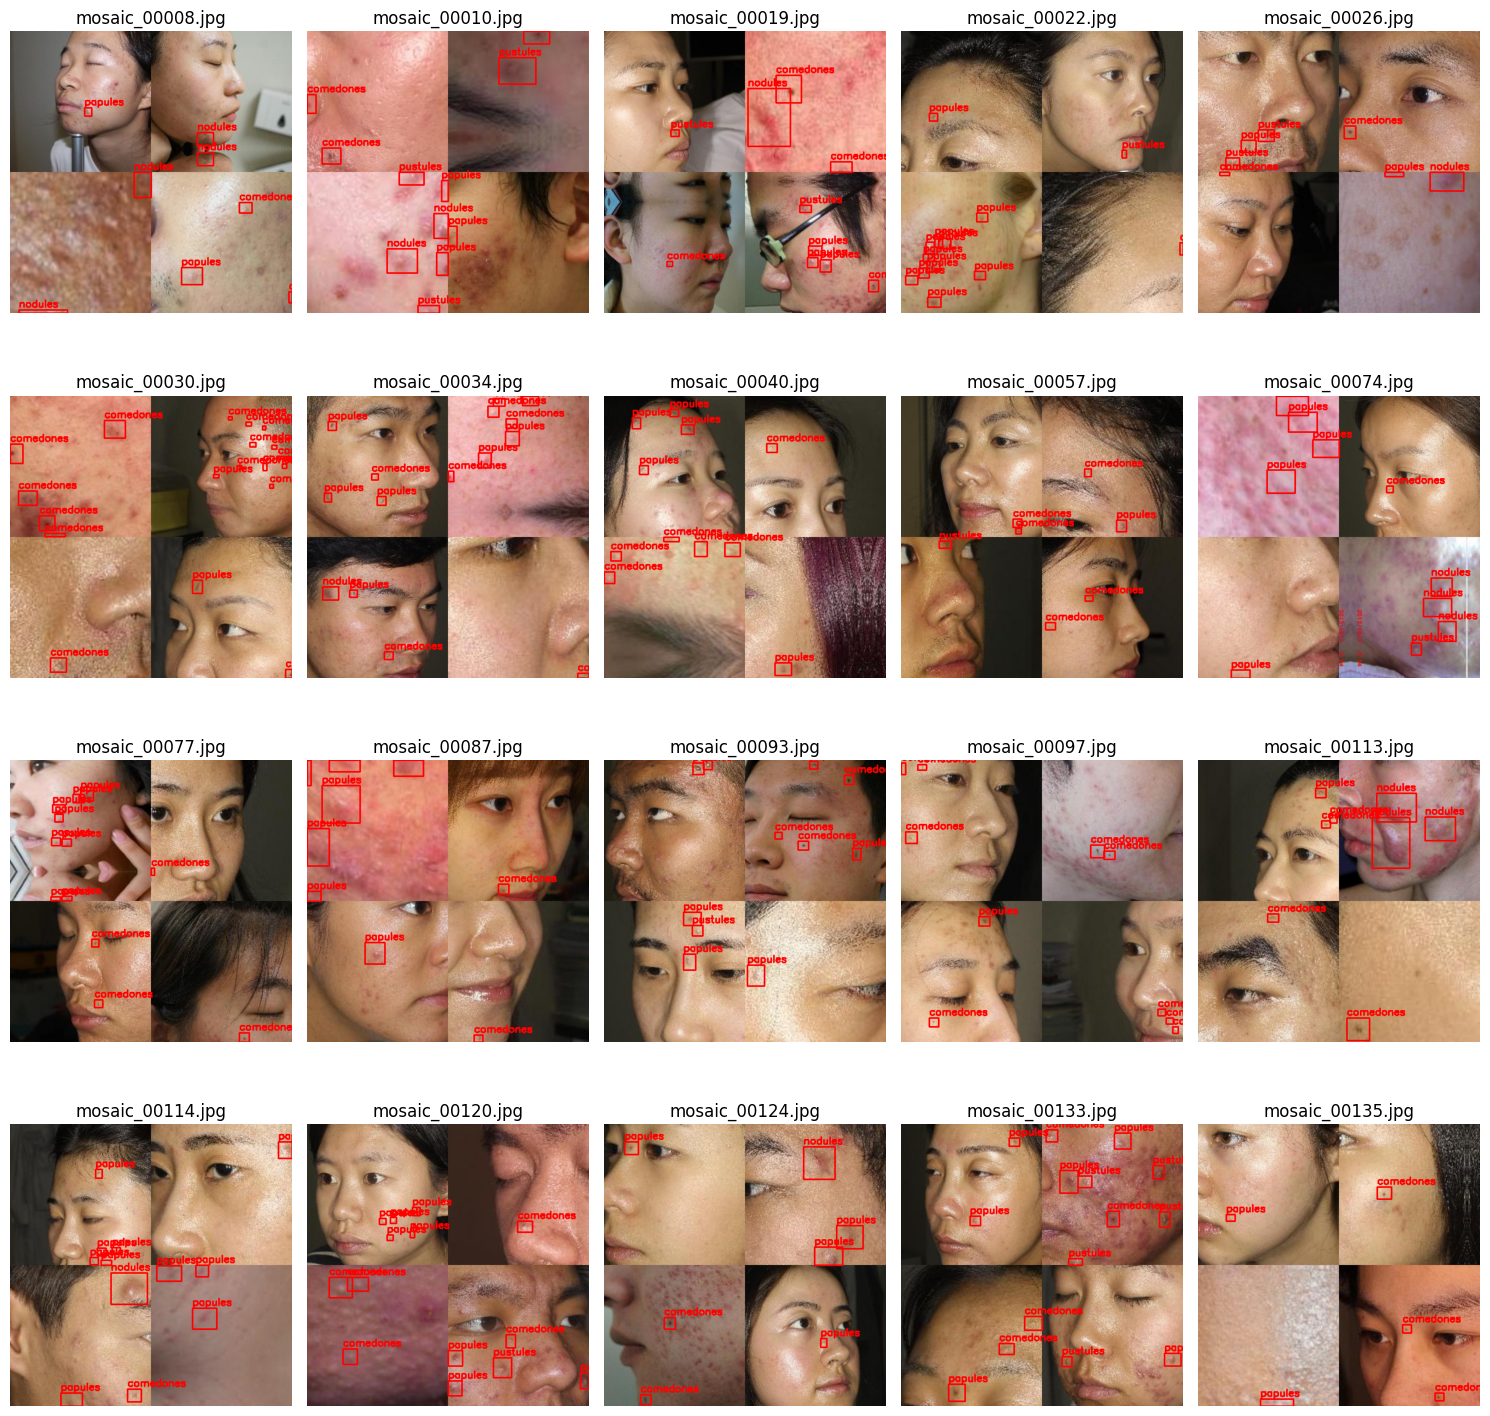

In [6]:
# ================== CÀI THƯ VIỆN ==================

# ================== IMPORT ==================
import os, json, cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

# ================== ĐƯỜNG DẪN ==================
img_dir = "train_aug"
json_path = os.path.join(img_dir, "_annotations.coco.json")

# ================== ĐỌC FILE JSON ==================
with open(json_path, "r", encoding="utf-8") as f:
    coco = json.load(f)

images = coco["images"]
annotations = coco["annotations"]
categories = {cat["id"]: cat["name"] for cat in coco["categories"]}

# ================== TẠO MAP ID ẢNH -> DANH SÁCH ANNOT ==================
image_to_anns = {}
for ann in annotations:
    img_id = ann["image_id"]
    if img_id not in image_to_anns:
        image_to_anns[img_id] = []
    image_to_anns[img_id].append(ann)

# ================== HIỂN THỊ 20 ẢNH ==================
num_show = min(20, len(images))
plt.figure(figsize=(15, 15))

count = 0
for img_info in images:
    if count >= num_show:
        break

    img_path = os.path.join(img_dir, img_info["file_name"])

    # kiểm tra file tồn tại
    if not os.path.exists(img_path):
        print(f"[⚠️] Không tìm thấy: {img_path}")
        continue

    img = cv2.imread(img_path)
    if img is None:
        print(f"[⚠️] Lỗi đọc ảnh: {img_path}")
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if img_info["id"] in image_to_anns:
        for ann in image_to_anns[img_info["id"]]:
            x, y, w, h = ann["bbox"]
            cat_name = categories[ann["category_id"]]
            cv2.rectangle(img, (int(x), int(y)), (int(x+w), int(y+h)), (255,0,0), 2)
            cv2.putText(img, cat_name, (int(x), int(y)-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)

    plt.subplot(4, 5, count+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_info["file_name"])
    count += 1

plt.tight_layout()
plt.show()
